In [47]:
import rasterio
from rasterio.plot import show
import scipy as sp
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pyproj import Transformer

In [2]:
cog_file_path = "ASC_EV_C_P_AU_TRN_N.cog.tif"
with rasterio.open(cog_file_path) as dataset:
    # Define the window for the bottom of the COG
    width = dataset.width
    height = dataset.height
    print("Metadata:", dataset.meta)
    data_crs = dataset.crs
    res = dataset.res
    transformation = dataset.transform
    band1 = dataset.read(1)

Metadata: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 49200, 'height': 40800, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0008333333333536583, 0.0, 112.999583333,
       0.0, -0.0008333333333578432, -10.000416666)}


In [3]:
# print(data_crs)
# data_crs = rasterio.crs.CRS.to_dict(data_crs)
# data_crs


In [4]:
res

(0.0008333333333536583, 0.0008333333333578432)

In [5]:
dataset = pd.DataFrame(band1)

In [6]:
#dataset.rename(columns=lambda a : a*res[0])

In [7]:
#dataset.rename(index=lambda a : a*res[1])

In [8]:
transformation = np.array(transformation)
transformation = np.reshape(transformation, (3,3))
transformation

array([[ 8.33333333e-04,  0.00000000e+00,  1.12999583e+02],
       [ 0.00000000e+00, -8.33333333e-04, -1.00004167e+01],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

In [9]:
dataset.rename(columns=lambda a : a*transformation[0,0]+transformation[0,2], inplace=True)

In [10]:
dataset.rename(index=lambda a : a*transformation[1,1]+transformation[1,2], inplace=True)

In [11]:
dataset.shape[0]

40800

In [12]:
n=50
smaller_dataset = dataset.iloc[range(0,dataset.shape[0],n),range(0,dataset.shape[1],n)]

In [13]:
smaller_dataset['latitude']=smaller_dataset.index

In [14]:
smaller_dataset = smaller_dataset.melt(id_vars='latitude', var_name='longitude')

In [15]:
smaller_dataset = smaller_dataset[smaller_dataset.value != 0]

In [30]:
smaller_dataset['value']
pd.unique(smalldata['value'])

array([11, 12,  4,  3,  2,  7,  8,  1,  9,  5, 14, 13, 10,  6])

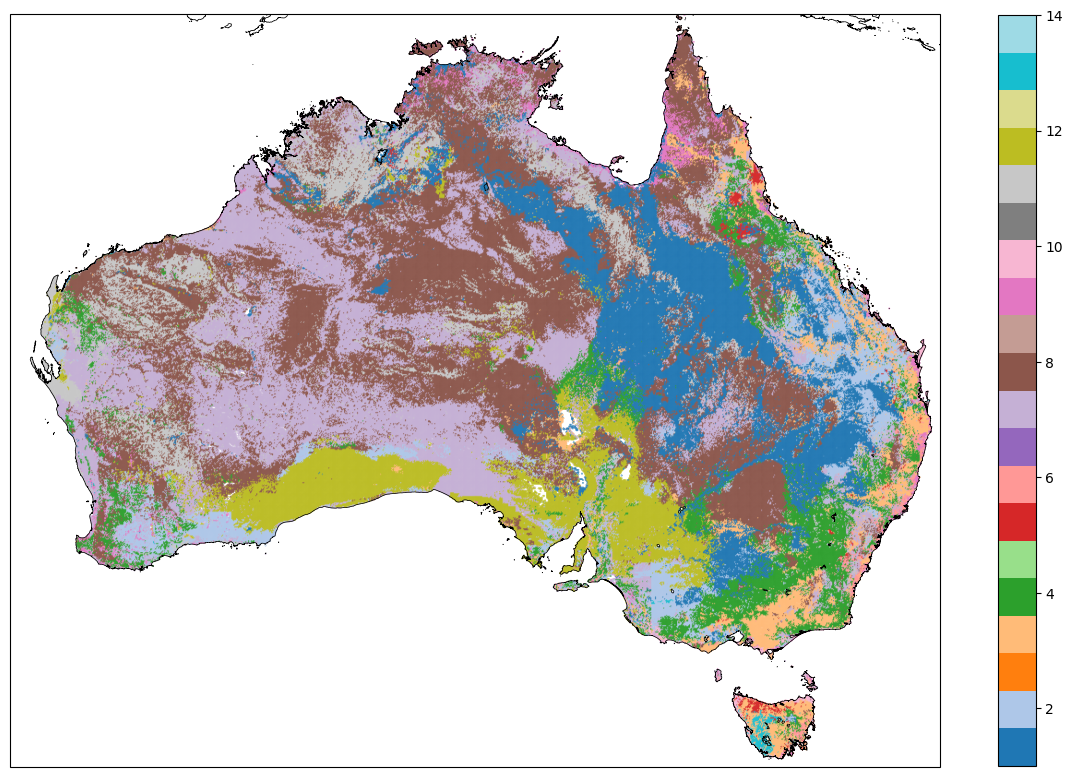

In [ ]:
# new soil data
from mpl_toolkits.basemap import Basemap
coordinates = (112, 154, -44, -10)

plt.figure(figsize=(15, 15))
m = Basemap(
    llcrnrlon=coordinates[0], llcrnrlat=coordinates[2],
    urcrnrlon=coordinates[1], urcrnrlat=coordinates[3],
    resolution='f')
ax = plt.axes(projection=ccrs.PlateCarree())
m.drawcoastlines(linewidth=.5)
cax=ax.scatter(smaller_dataset['longitude'], smaller_dataset['latitude'], s=0.1, c=smaller_dataset['value'], cmap='tab20')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.show()

In [33]:
soils=pd.unique(griddata['Soil_class'])
soils

<StringArray>
[   'Rudosols',    'Podosols',   'Hydrosols',   'Kandosols',  'Organosols',
   'Ferrosols',    'Kurosols',  'Chromosols',   'Dermosols', 'Calcarosols',
    'Sodosols',    'Tenosols',   'Vertosols']
Length: 13, dtype: str

In [36]:
soils=pd.unique(griddata['Soil_class'])
numbers=[11,10,9,8,13,5,6,4,3,12,2,7,1]

soil_numbers= dict(zip(soils, numbers))
griddata.replace(to_replace=soil_numbers, inplace=True)
griddata

,Longitude,Latitude,Soil_class
0,113.25,-26.20,11
1,113.25,-26.25,11
2,113.30,-26.15,11
3,113.30,-26.25,11
4,113.30,-26.30,11
...,...,...,...
277085,153.45,-27.60,10
277086,153.45,-27.65,10
277087,153.45,-27.70,10
277088,153.50,-27.45,10


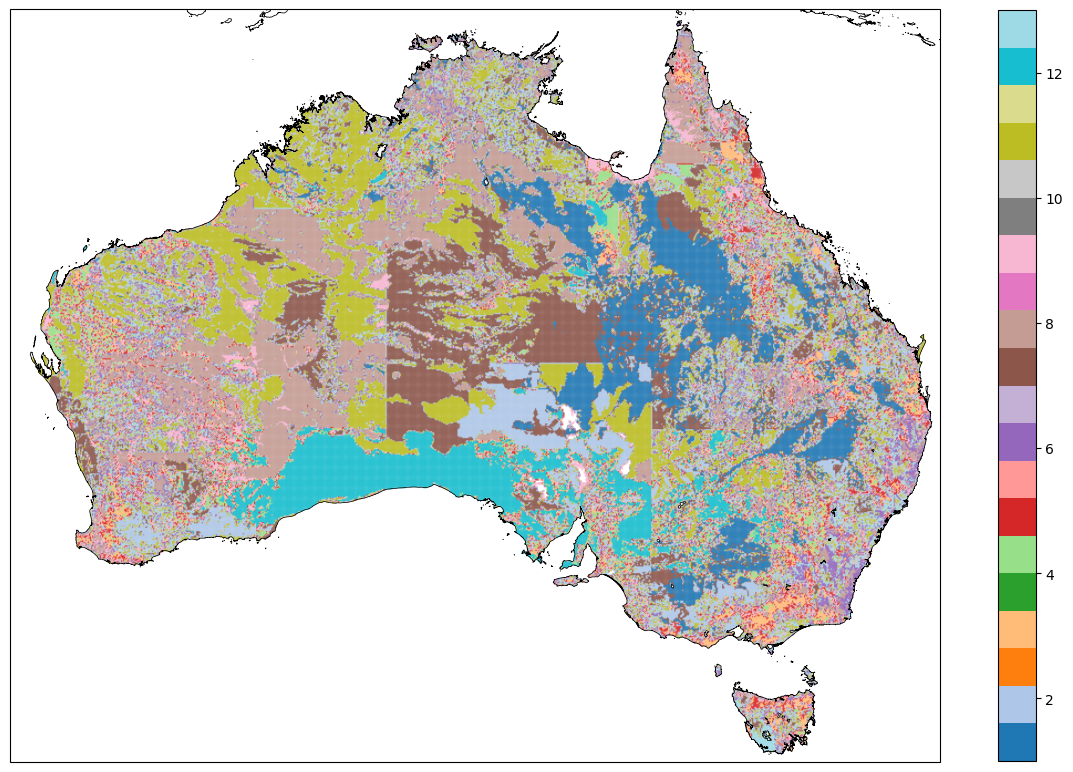

In [ ]:
# old soil data with lots of anomalies

coordinates = (112, 154, -44, -10)


plt.figure(figsize=(15, 15))
m = Basemap(
    llcrnrlon=coordinates[0], llcrnrlat=coordinates[2],
    urcrnrlon=coordinates[1], urcrnrlat=coordinates[3],
    resolution='f')
ax = plt.axes(projection=ccrs.PlateCarree())
m.drawcoastlines(linewidth=.5)
cax=ax.scatter(griddata['Longitude'], griddata['Latitude'], s=0.1, c=griddata['Soil_class'], cmap='tab20')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.show()

In [31]:
griddata = pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-gridded.csv?raw=true")

In [20]:
smalldata= pd.read_csv('soil-type-aus-new-small.csv')
smalldata.drop(labels='ID', axis=1, inplace=True)
smalldata.info()

<class 'pandas.DataFrame'>
RangeIndex: 397585 entries, 0 to 397584
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   latitude   397585 non-null  float64
 1   longitude  397585 non-null  float64
 2   value      397585 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 9.1 MB


In [35]:
griddata.drop(labels=['Elevation','Distance_to_coast','Rainfall','Seasonal_rainfall_zone','PET','NDVI','Clay_fraction'], axis=1, inplace=True)
griddata.info()

<class 'pandas.DataFrame'>
RangeIndex: 277090 entries, 0 to 277089
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Longitude   277090 non-null  float64
 1   Latitude    277090 non-null  float64
 2   Soil_class  277090 non-null  object 
dtypes: float64(2), object(1)
memory usage: 6.3+ MB


In [39]:
griddata.to_csv(path_or_buf='soil-type-aus-old-gridded.csv')

In [60]:
#interpolate new data to old resolution using scipy

lonlat_fine = np.vstack((smalldata['longitude'], smalldata['latitude']),dtype=float).T
lonlat_coarse = np.vstack((griddata['Longitude'],griddata['Latitude']),dtype=float).T

values_fine = np.array(smalldata['value']) 


values_interp_coarse = sp.interpolate.griddata(lonlat_fine, values_fine, lonlat_coarse, method='nearest')
values_coarse_rounded = np.rint(values_interp_coarse)
values_coarse_rounded


array([11., 11., 11., ..., 10., 13., 10.], shape=(277090,))

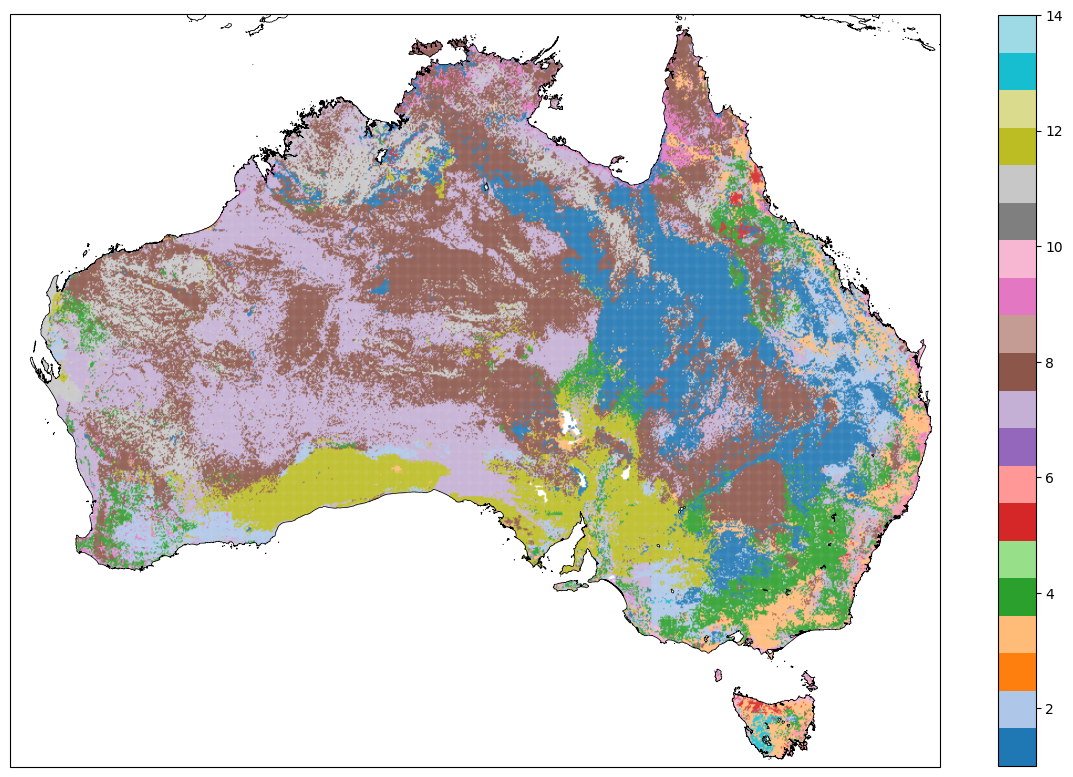

In [61]:
coordinates = (112, 154, -44, -10)


plt.figure(figsize=(15, 15))
m = Basemap(
    llcrnrlon=coordinates[0], llcrnrlat=coordinates[2],
    urcrnrlon=coordinates[1], urcrnrlat=coordinates[3],
    resolution='f')
ax = plt.axes(projection=ccrs.PlateCarree())
m.drawcoastlines(linewidth=.5)
cax=ax.scatter(griddata['Longitude'], griddata['Latitude'], s=0.1, c=values_coarse_rounded, cmap='tab20')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.show()

In [62]:
olddata = pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-gridded.csv?raw=true")
olddata['Soil_class'] = values_coarse_rounded
olddata.to_csv(path_or_buf='recharge-australia_data-gridded-updated-soils.csv')